In [1]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, tan, einsum
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator, graphene_conductivity
from utils import c, hbar, alpha
tau = 6.4*1e-13; # scattering time in seconds

In [2]:
M = 10000
epsilon = 2.1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [3]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigmas_real = sigmas[0, :] # real part of surface conductivity at CPA
sigmas_imaginary = sigmas[1, :] # imaginary part of surface conductivity at CPA
# The quasistatic dispersion (from the plasmon dispersion)
quasistatic_dispersion = x*(l*epsilon+(l+1))/(l*(l+1))

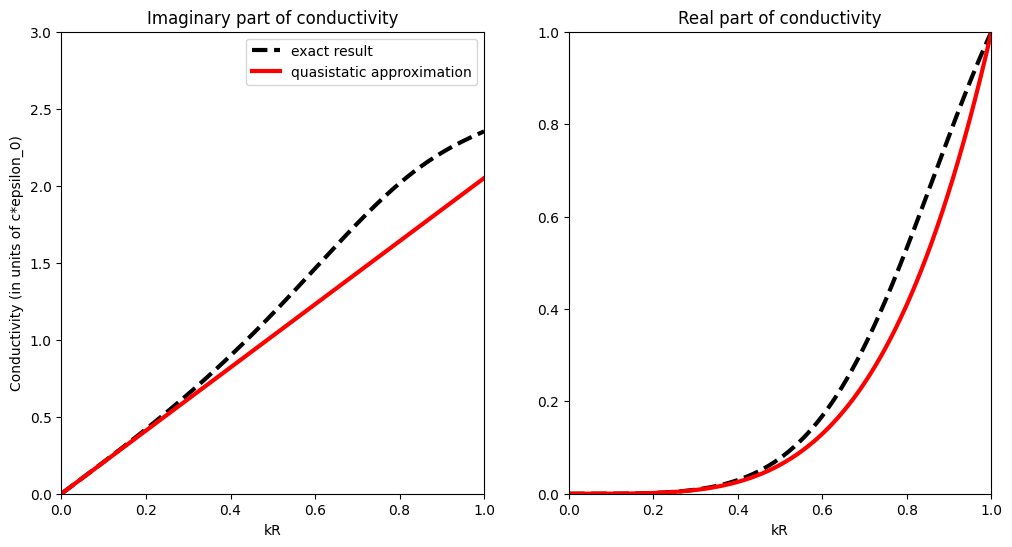

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, sigmas_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, quasistatic_dispersion, label="quasistatic approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 3)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigmas_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.plot(x, x**4, label="", color="red", linestyle="solid", linewidth=3)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");

In [5]:
s_sqrds = abs(e_r_cpa(l, x, epsilon, 1j*(sigmas_real + 1j*sigmas_imaginary)/x))**2
tm_numerator = abs(e_r_cpa_numerator(l, x, epsilon, 1j*(sigmas_real + 1j*sigmas_imaginary)/x))
print("Maximum value for |s|^2: ", s_sqrds.max())
print("Maximum (absolute) value for the cpa numerator", tm_numerator.max())

Maximum value for |s|^2:  3.784555824036611e-14
Maximum (absolute) value for the cpa numerator 5.684341886080801e-13


In [6]:
a = c*tau*x*sigmas_real/sigmas_imaginary; # sphere radii at CPA
hbar_omega = hbar*(sigmas_imaginary/sigmas_real)*(1/tau) # angular frequencies (in eV) at CPA
E_F = (hbar/tau)*(sigmas_real**2+sigmas_imaginary**2)/(4*sigmas_real)/alpha; # Fermi energies in eV at CPA

In [7]:
N = 10000
cpa_idxs = [5000, 6000, 7000, 8000, 9000] # Sweep from ka = 0.5 to 0.9
E_F_real_v = zeros((len(cpa_idxs), N)) 
E_F_imaginary_v = zeros((len(cpa_idxs), N))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    hbar_omega_cpa = hbar_omega[cpa_idx]
    hbar_omega_off_cpa_range = linspace(hbar_omega_cpa/4, hbar_omega_cpa*7/4, N)
    E_F_real = 1/(4*alpha)*(hbar_omega_off_cpa_range*sigmas_imaginary[cpa_idx]+(hbar/tau)*sigmas_real[cpa_idx])
    E_F_imaginary = 1/(4*alpha)*(-hbar_omega_off_cpa_range*sigmas_real[cpa_idx]+(hbar/tau)*sigmas_imaginary[cpa_idx])
    E_F_real_v[idx, :] = E_F_real
    E_F_imaginary_v[idx, :] = E_F_imaginary

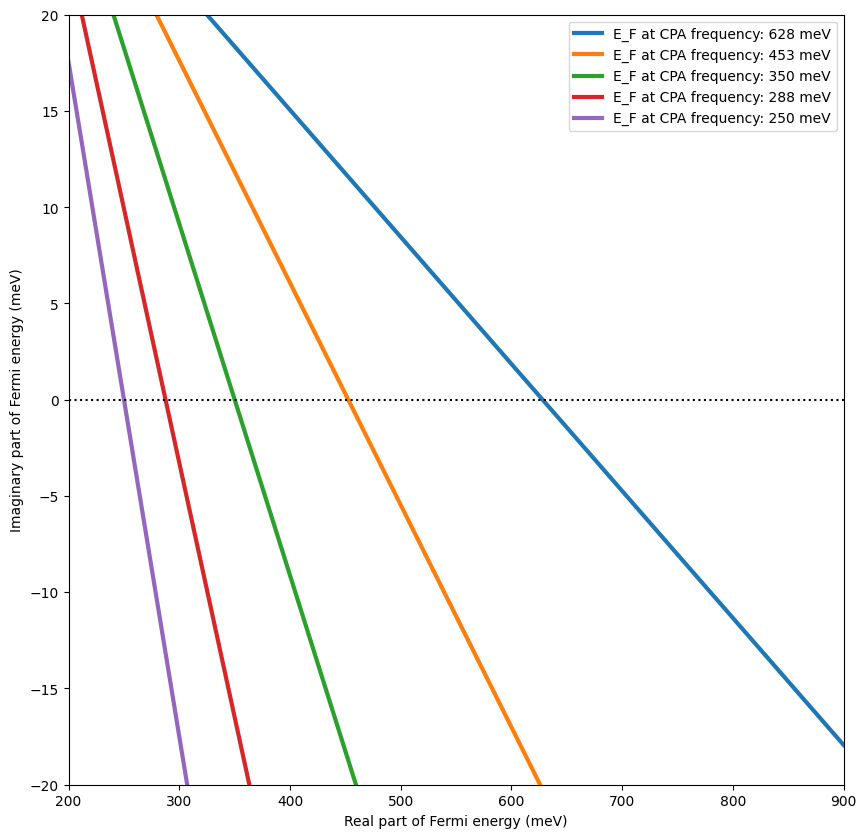

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    E_F_real = E_F_real_v[idx, :]
    E_F_imaginary = E_F_imaginary_v[idx, :]
    E_F_CPA = E_F_real[np.argmin(np.abs(E_F_imaginary))]
    ax.plot(E_F_real*1e3, E_F_imaginary*1e3, linestyle="solid", linewidth=3, label=f"E_F at CPA frequency: {round(E_F_CPA*1e3)} meV")
ax.set_ylim(-20, 20);
ax.set_xlim(200, 900);
ax.hlines([0], 200, 900, color="black", linestyle="dotted")
ax.set_xlabel("Real part of Fermi energy (meV)")
ax.set_ylabel("Imaginary part of Fermi energy (meV)");
ax.legend();

## Now we find the correct (frequency, scattering rate) pair for a fixed Fermi energy 

In [9]:
cpa_idxs = [5000, 6000, 7000, 8000, 9000]
N = 10000
taus_v = zeros((len(cpa_idxs), N))
hbar_omegas_v = zeros((len(cpa_idxs), N))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    E_F_cpa = E_F[cpa_idx]
    E_F_off_cpa_range = linspace(E_F_cpa/3, E_F_cpa*3, N)
    taus = (hbar/E_F_off_cpa_range)*(sigmas_real[cpa_idx]**2+sigmas_imaginary[cpa_idx]**2)/(4*alpha*sigmas_real[cpa_idx])
    hbar_omegas = E_F_off_cpa_range*(4*alpha*sigmas_imaginary[cpa_idx])/(sigmas_real[cpa_idx]**2+sigmas_imaginary[cpa_idx]**2)
    taus_v[idx, :] = taus
    hbar_omegas_v[idx, :] = hbar_omegas

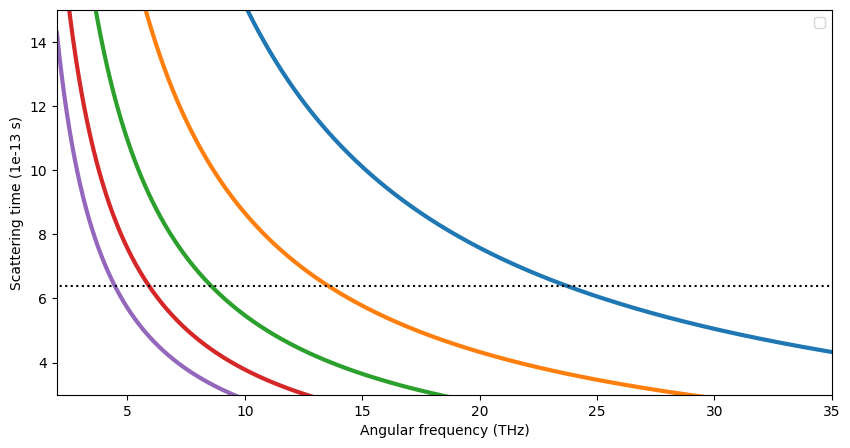

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
tau_64_idx = np.argmin(np.abs(linspace(1/3, 3, N)-1))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    taus_100fs = taus_v[idx, :]*1e13
    hbar_omegas_thz = hbar_omegas_v[idx, :]/(hbar*1e12)
    where_crosses_tau_64 = np.argmin(np.abs(taus_100fs-6.4)) 
    assert where_crosses_tau_64 == tau_64_idx # Where the lines below cross tau=6.4 should correspond to the index at which the Fermi energy is the CPA Fermi energy 
    ax.plot(hbar_omegas_thz, taus_100fs, linestyle="solid", linewidth=3)
ax.hlines([6.4], 0, 100, color="black", linestyle="dotted")
ax.set_xlabel("Angular frequency (THz)")
ax.set_ylabel("Scattering time (1e-13 s)");
ax.set_ylim(3, 15);
ax.set_xlim(2, 35);
ax.legend();

## Now we track the complex bulk dielectric constant as we tune the conductivity off CPA

In [11]:
N = 20 # Make a smaller number so we can clearly see the spheres
M = 500
epsilon_reals = linspace(-2.6, 2.6, M) + epsilon # Range of real part of the dielectric function offset by the epsilon for which we calculated cpa
epsilon_imaginaries = 1j*linspace(-1e-3, 1e-3, M) # Range of imaginary part of the dielectric function
epsilon_array = epsilon_reals.reshape((M, 1)).repeat(M, axis=1) + epsilon_imaginaries.reshape((1, M)).repeat(M, axis=0)

In [12]:
epsilons_real_cpa_v = []
epsilons_imaginary_cpa_v = [] 
sigma_imaginaries_off_cpa_v = []
for cpa_idx in cpa_idxs:
    print("cpa_idx: ", cpa_idx);
    sigma_imaginaries_off_cpa = sigmas_imaginary[cpa_idx] * (1 + linspace(-0.5, 0.5, N))
    sigma_imaginaries_off_cpa_v.append(sigma_imaginaries_off_cpa)
    epsilons_real_cpa = np.zeros(N)
    epsilons_imaginary_cpa = np.zeros(N)
    for (idx, sigma_imaginary_off_cpa) in enumerate(sigma_imaginaries_off_cpa):
        s_sqrds = abs(e_r_cpa(l, x[cpa_idx], epsilon_array, 1j*(sigmas_real[cpa_idx] + 1j*sigma_imaginary_off_cpa)/x[cpa_idx]))**2
        assert s_sqrds.min() < 0.01
        argmin_idx = unravel_index(s_sqrds.argmin(), (M, M))
        epsilons_real_cpa[idx] = epsilon_array[argmin_idx].real
        epsilons_imaginary_cpa[idx] = epsilon_array[argmin_idx].imag
    epsilons_real_cpa_v.append(epsilons_real_cpa)
    epsilons_imaginary_cpa_v.append(epsilons_imaginary_cpa)

cpa_idx:  5000
cpa_idx:  6000
cpa_idx:  7000
cpa_idx:  8000
cpa_idx:  9000


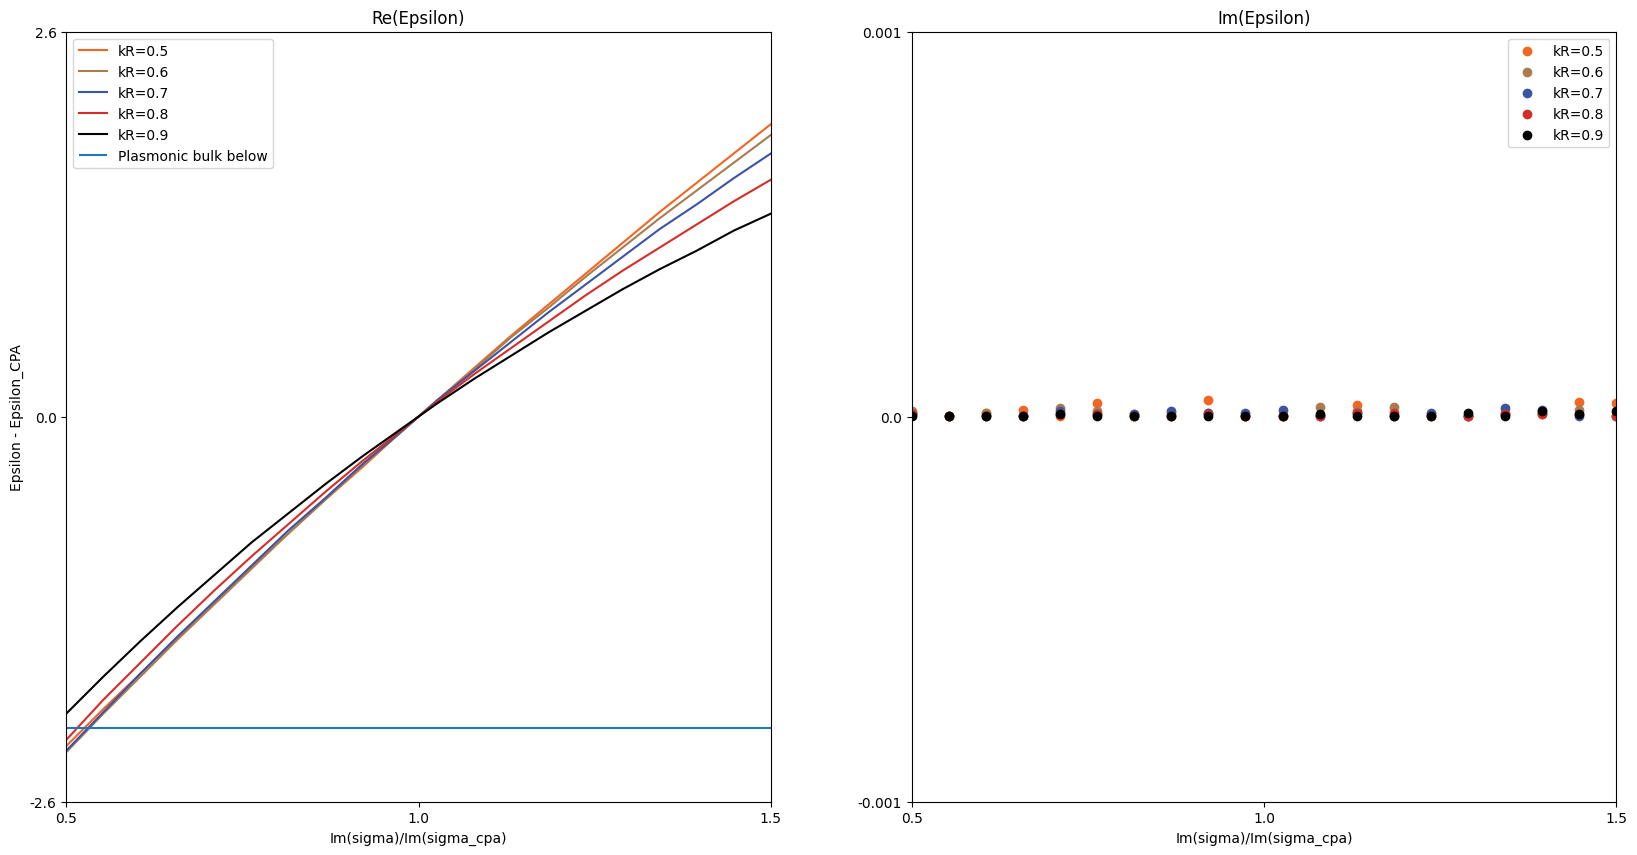

In [13]:
colors = ['#f26522', '#a97c50', '#3b54a4', '#d52d28', '#010202' ]
ax1_min = epsilon_reals.min()
ax1_max = epsilon_reals.max()
ax2_min = epsilon_imaginaries.imag.min()
ax2_max = epsilon_imaginaries.imag.max()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    color = colors[idx]
    #ax1.scatter(sigma_imaginaries_off_cpa_v[idx]/sigmas_imaginary[cpa_idx], epsilons_real_cpa_v[idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")
    ax1.plot(sigma_imaginaries_off_cpa_v[idx]/sigmas_imaginary[cpa_idx], epsilons_real_cpa_v[idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")
    ax2.scatter(sigma_imaginaries_off_cpa_v[idx]/sigmas_imaginary[cpa_idx], epsilons_imaginary_cpa_v[idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")

ax1.hlines([0], 0.5, 1.5, label="Plasmonic bulk below")
ax1.legend()
ax2.legend()
ax1.set_xlim(0.5, 1.5);
ax2.set_xlim(0.5, 1.5);

ax1.set_title("Re(Epsilon)")
ax2.set_title("Im(Epsilon)")

ax1.set_xlabel("Im(sigma)/Im(sigma_cpa)")
ax2.set_xlabel("Im(sigma)/Im(sigma_cpa)");

ax2.set_ylim(ax2_min, ax2_max);
ax1.set_ylim(ax1_min, ax1_max);
#ax1.set_ylim(epsilon-2.6, epsilon+2.6)
ax1.set_yticks([ax1_min, epsilon, ax1_max], (np.array([ax1_min, epsilon, ax1_max]) - epsilon).round(3))
ax2.set_yticks([ax2_min, 0, ax2_max], np.array([ax2_min, 0, ax2_max]).round(3))

ax1.set_xticks([0.5, 1, 1.5]);
ax2.set_xticks([0.5, 1, 1.5]);
ax1.set_ylabel("Epsilon - Epsilon_CPA");
plt.savefig("./paper/track_real_epsilon_off_cpa.pdf");

In [14]:
N = 20
M = 500
epsilon_reals = linspace(-0.001, 0.04, M) + epsilon
epsilon_imaginaries = 1j*linspace(-1, 1, M)
epsilon_array = epsilon_reals.reshape((M, 1)).repeat(M, axis=1) + epsilon_imaginaries.reshape((1, M)).repeat(M, axis=0)

In [15]:
epsilons_real_cpa_v = []
epsilons_imaginary_cpa_v = [] 
sigma_reals_off_cpa_v = []

for (idx, cpa_idx) in enumerate(cpa_idxs):
    print("cpa_idx: ", cpa_idx);
    sigma_reals_off_cpa = sigmas_real[cpa_idx]*(1 + np.linspace(-0.5, 0.5, N))
    sigma_reals_off_cpa_v.append(sigma_reals_off_cpa)

    epsilons_real_cpa = np.zeros(N)
    epsilons_imaginary_cpa = np.zeros(N)
    
    for (idx, sigma_real_off_cpa) in enumerate(sigma_reals_off_cpa):
        s_sqrds = abs(e_r_cpa(l, x[cpa_idx], epsilon_array, 1j*(sigma_real_off_cpa + 1j*sigmas_imaginary[cpa_idx])/x[cpa_idx]))**2
        assert s_sqrds.min() < 1e-3
        argmin_idx = unravel_index(s_sqrds.argmin(), (M, M))
        epsilons_real_cpa[idx] = epsilon_array[argmin_idx].real
        epsilons_imaginary_cpa[idx] = epsilon_array[argmin_idx].imag
    epsilons_real_cpa_v.append(epsilons_real_cpa)
    epsilons_imaginary_cpa_v.append(epsilons_imaginary_cpa)

cpa_idx:  5000
cpa_idx:  6000
cpa_idx:  7000
cpa_idx:  8000
cpa_idx:  9000


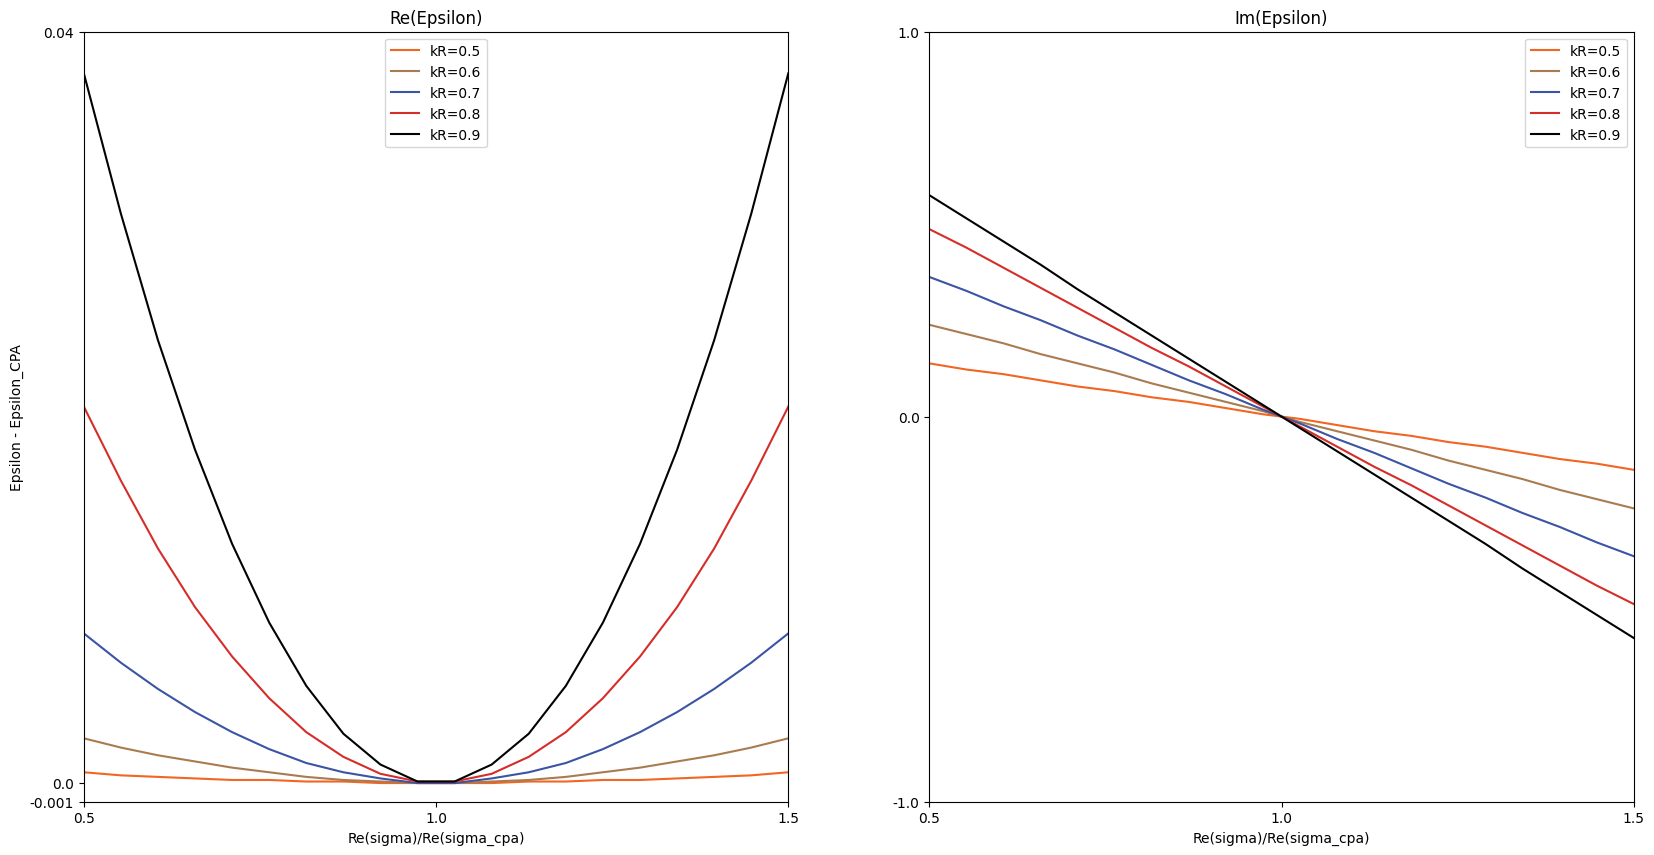

In [16]:
ax1_min = epsilon_reals.min()
ax1_max = epsilon_reals.max()
ax2_min = epsilon_imaginaries.imag.min()
ax2_max = epsilon_imaginaries.imag.max()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    color = colors[idx]
    #ax1.scatter(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx], epsilons_real_cpa_v[idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")
    ax1.plot(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx], epsilons_real_cpa_v[idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")
    #ax2.scatter(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx], epsilons_imaginary_cpa_v[idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")
    ax2.plot(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx], epsilons_imaginary_cpa_v[idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")

ax1.legend()
ax2.legend()
ax1.set_xlim(0.5, 1.5);
ax2.set_xlim(0.5, 1.5);

ax1.set_title("Re(Epsilon)")
ax2.set_title("Im(Epsilon)")

ax1.set_xlabel("Re(sigma)/Re(sigma_cpa)")
ax2.set_xlabel("Re(sigma)/Re(sigma_cpa)");

ax2.set_ylim(ax2_min, ax2_max);
ax1.set_ylim(ax1_min, ax1_max);
ax1.set_yticks([ax1_min, epsilon, ax1_max], (np.array([ax1_min, epsilon, ax1_max]) - epsilon).round(3))
ax2.set_yticks([ax2_min, 0, ax2_max], np.array([ax2_min, 0, ax2_max]).round(3))

ax1.set_xticks([0.5, 1, 1.5]);
ax2.set_xticks([0.5, 1, 1.5]);
ax1.set_ylabel("Epsilon - Epsilon_CPA");
plt.savefig("./paper/track_imag_epsilon_off_cpa.pdf");

## We now print out some of the values from the figure above as a sanity check

In [23]:
print("Change in the real part of epsilon for kR = 0.9: ", epsilons_real_cpa_v[4][0] - epsilon)
print("Change in the imaginary part of epsilon for kR = 0.9: ", epsilons_imaginary_cpa_v[4][0])

Change in the real part of epsilon for kR = 0.9:  0.03778156312625258
Change in the imaginary part of epsilon for kR = 0.9:  0.5751503006012022


## Now we track the complex valued frequency as we change the radius off CPA

In [24]:
cpa_idxs = [5000, 6000, 7000, 8000, 9000]
M = int(2e2)
N = 20
tau_reshaped = tau * ones((M, M))
optimal_real_omegas_v = []
optimal_imag_omegas_v = []

for (idx, cpa_idx) in enumerate(cpa_idxs):
    print("cpa_idx: ", cpa_idx)
    hbar_omega_cpa = hbar_omega[cpa_idx]
    omega_real_range = linspace(0.8, 1.2, M)*hbar_omega_cpa
    omega_imag_range = linspace(-1e-4, 1e-4, M)
    
    hbar_omega_off_cpa = omega_real_range.reshape((M, 1)).repeat(M, axis=1) + 1j*omega_imag_range.reshape((1, M)).repeat(M, axis=0)
    E_F_cpa = E_F[cpa_idx]
    a_cpa = a[cpa_idx]
    
    a_off_cpas = a_cpa*linspace(0.9, 1.1, N)
    
    optimal_real_omegas = zeros(N)
    optimal_imag_omegas = zeros(N)
    
    for (a_idx, a_off_cpa) in enumerate(a_off_cpas):
        x_s = hbar_omega_off_cpa * a_off_cpa/(c*hbar) # keep radius fixed
        sigmas = graphene_conductivity(E_F_cpa, hbar_omega_off_cpa, hbar/tau_reshaped, include_interband=False)
        g_omegas = sigmas*1j/x_s
        s_sqrds = abs(e_r_cpa(l, x_s, epsilon, g_omegas))**2
        assert s_sqrds.min() < 1e-3
        row, col = unravel_index(s_sqrds.argmin(), (M, M))
        optimal_real_omegas[a_idx] = omega_real_range[row] 
        optimal_imag_omegas[a_idx] = omega_imag_range[col] 
    optimal_imag_omegas_v.append(optimal_imag_omegas)
    optimal_real_omegas_v.append(optimal_real_omegas)

cpa_idx:  5000
cpa_idx:  6000
cpa_idx:  7000
cpa_idx:  8000
cpa_idx:  9000


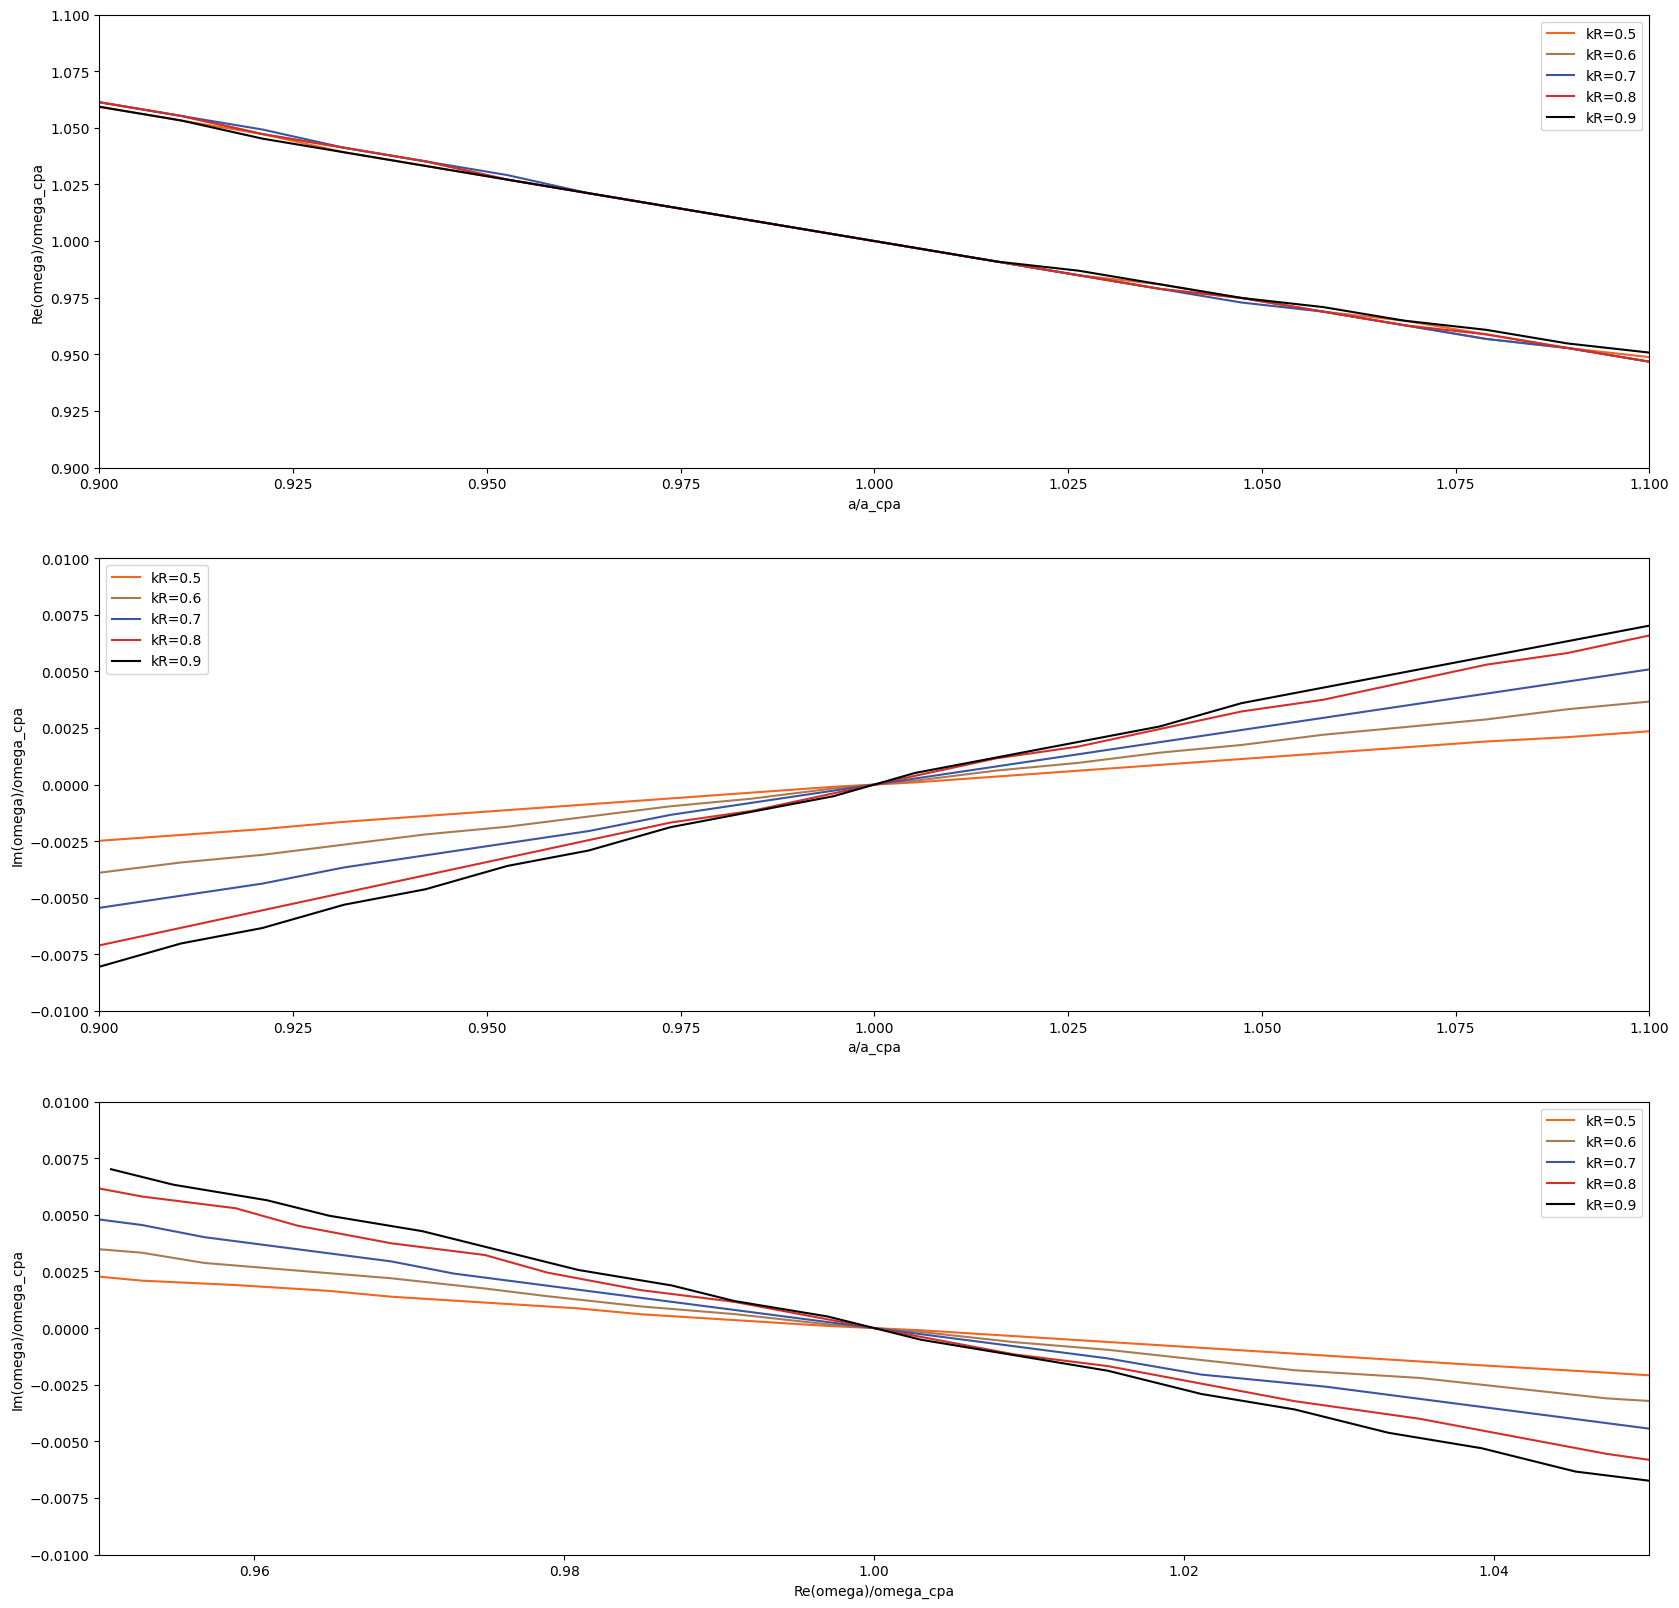

In [25]:
s=60
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 20))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    color = colors[idx]
    #ax1.scatter(linspace(0.9, 1.1, N), optimal_real_omegas_v[idx]/hbar_omega[cpa_idx], s=s, label=f"kR={round(x[cpa_idx], 2)}")
    #ax2.scatter(linspace(0.9, 1.1, N), optimal_imag_omegas_v[idx]/hbar_omega[cpa_idx], s=s, label=f"kR={round(x[cpa_idx], 2)}")
    #ax3.scatter(optimal_real_omegas_v[idx]/hbar_omega[cpa_idx], optimal_imag_omegas_v[idx]/hbar_omega[cpa_idx], s=s, label=f"kR={round(x[cpa_idx], 2)}")
    ax1.plot(linspace(0.9, 1.1, N), optimal_real_omegas_v[idx]/hbar_omega[cpa_idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")
    ax2.plot(linspace(0.9, 1.1, N), optimal_imag_omegas_v[idx]/hbar_omega[cpa_idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")
    ax3.plot(optimal_real_omegas_v[idx]/hbar_omega[cpa_idx], optimal_imag_omegas_v[idx]/hbar_omega[cpa_idx], color=color, label=f"kR={round(x[cpa_idx], 2)}")

ax1.set_xlabel("a/a_cpa")
ax2.set_xlabel("a/a_cpa")
ax1.set_ylabel("Re(omega)/omega_cpa")
ax2.set_ylabel("Im(omega)/omega_cpa");
ax3.set_xlabel("Re(omega)/omega_cpa")
ax3.set_ylabel("Im(omega)/omega_cpa");
ax1.set_xlim(0.9, 1.1)
ax2.set_xlim(0.9, 1.1);
ax1.set_ylim(0.9, 1.1);
ax2.set_ylim(-1e-2, 1e-2);
ax3.set_ylim(-1e-2, 1e-2);
ax3.set_xlim(0.95, 1.05);
ax1.legend();ax2.legend();ax3.legend();
plt.savefig("./paper/track_complex_frequencies_off_cpa.pdf");